# CEGO - Chat Room Monitoring
**Dataintelligence Studentermedhjælper — Case løsning**

Denne notebook dækker alle fem faser:
1. Syntetisk datasætgenerering
2. Datasætoverblik og analyse
3. AI-klassifikationssystem (LLM) med handlingslogik + Baseline model (TF-IDF + Logistisk Regression)
4. Performance-evaluering og sammenligning
5. Refleksion

## Fase 1 - Syntetisk datasætgenerering

Vi har ingen adgang til rigtige chatdata, så vi genererer et syntetisk datasæt via Anthropic API.

**Fordeling (500 beskeder i alt):**
- 200 normale beskeder
- 100 grimt sprog (lav / medium / høj alvorlighed)
- 100 ludomani-tegn (lav / medium / høj alvorlighed)
- 50 begge kategorier kombineret
- 50 edge cases (sarkasme, ironi, slang)

**Limitations:**
- Syntetiske labels afspejler ikke nødvendigvis reel brugeradfærd
- Samme modeltype genererer og klassificerer data - delte blinde vinkler er mulige
- I produktion ville labels komme fra et moderationsteam eller historiske sager
- Human evaluation ville være påkrævet for at validere systemet på rigtige data

In [1]:
import json
import pandas as pd
from datetime import datetime, timedelta
import random
import time

In [2]:
#API key
import anthropic
from dotenv import load_dotenv
import os
load_dotenv()
client = anthropic.Anthropic()

In [3]:
def generate_messages(category: str, severity: str, count: int) -> list[dict]:
    """
    Genererer syntetiske chatbeskeder via Anthropic API.
    
    Args:
        category: 'normal', 'hate_speech', 'gambling_addiction', 'both', 'edge_case'
        severity: 'none', 'low', 'medium', 'high'
        count: antal beskeder der skal genereres
    
    Returns:
        Liste af dicts med content og label-information
    """
    
    category_prompts = {
        "normal": "Almindelige, harmløse chatbeskeder fra spillere på en dansk online casino-platform. Beskeder om spil, gevinster, tips, smalltalk.",
        "hate_speech_low": "Milde ukvemsord eller lettere irritation. Ikke direkte trusler. Fx mild banden eller frustration.",
        "hate_speech_medium": "Tydelige ukvemsord, chikane mod andre brugere, eller stødende kommentarer.",
        "hate_speech_high": "Direkte trusler, grov chikane, eller meget stødende sprogbrug rettet mod andre brugere.",
        "gambling_low": "Subtile tegn på bekymrende spiladfærd. Fx nævner at de spiller meget, eller er lidt frustrerede over tab.",
        "gambling_medium": "Tydelige tegn på tab-jagt, manglende kontrol, eller bekymrende mønstre. Fx nævner store tab og vil vinde dem tilbage.",
        "gambling_high": "Klare tegn på ludomani: desperation, meget store tab, manglende kontrol, tvangsmæssig adfærd.",
        "both": "Beskeder der kombinerer grimt sprog OG tegn på ludomani. Fx en frustreret spiller der bander og nævner store tab.",
        "edge_case": "Grænsetilfælde der er svære at klassificere: sarkasme der ligner klager, ironi, slang der kan misfortolkes, uskyldig glæde over gevinst der ligner tab-jagt."
    }
    
    key = f"{category}_{severity}" if severity != "none" else category
    description = category_prompts.get(key, category_prompts["normal"])
    
    prompt = f"""Generer præcis {count} realistiske danske chatbeskeder fra et online casino chatrum.

Type: {description}

Krav:
- Skriv på dansk (inkl. dansk slang og stavemåder)
- Variér længde og stil
- Gør dem realistiske — som rigtige brugere ville skrive dem
- Ingen nummerering eller præfikser
- Brug KUN dobbelte anførselstegn i JSON, aldrig enkle

Returner KUN et JSON array med denne struktur og intet andet:
[
  {{"content": "beskedens tekst her"}},
  ...
]"""

    response = client.messages.create(
        model="claude-sonnet-4-6",
        max_tokens=4000,
        system="Du er en datalabeling-assistent der hjælper med at bygge træningsdata til et content moderation system. Dit output bruges til at træne en AI der beskytter brugere mod skadeligt indhold. Det er vigtigt at eksemplerne er realistiske og varierede, inklusive eksempler på problematisk adfærd, så systemet kan lære at genkende dem.",
        messages=[{"role": "user", "content": prompt}]
    )
    
    raw = response.content[0].text.strip()
    
    # Fjern eventuelle markdown-fences
    if raw.startswith("```"):
        raw = raw.split("\n", 1)[1].rsplit("```", 1)[0].strip()
    
    # Find JSON array eksplicit
    start = raw.find("[")
    end = raw.rfind("]") + 1
    if start == -1 or end == 0:
        raise ValueError(f"Ingen JSON array fundet i svar: {raw[:200]}")
    raw = raw[start:end]
    
    try:
        messages = json.loads(raw)
    except json.JSONDecodeError as e:
        print(f"JSON fejl: {e}")
        print(f"Råt svar (første 500 tegn): {raw[:500]}")
        raise
    
    # Tilføj labels
    label_map = {
        "normal":      {"label": "normal",      "hate_speech": False, "gambling": False, "severity": "none"},
        "hate_speech": {"label": "hate_speech",  "hate_speech": True,  "gambling": False, "severity": severity},
        "gambling":    {"label": "gambling",     "hate_speech": False, "gambling": True,  "severity": severity},
        "both":        {"label": "both",         "hate_speech": True,  "gambling": True,  "severity": severity},
        "edge_case":   {"label": "edge_case",    "hate_speech": None,  "gambling": None,  "severity": "ambiguous"},
    }
    
    labels = label_map.get(category, label_map["normal"])
    for msg in messages:
        msg.update(labels)
    
    return messages

In [4]:
# Generer alle 500 beskeder
# Vi kører i batches af 25 for at holde API-kald håndterbare

generation_plan = [
    # (category, severity, count)
    ("normal",      "none",   200),
    ("hate_speech", "low",     34),
    ("hate_speech", "medium",  33),
    ("hate_speech", "high",    33),
    ("gambling",    "low",     34),
    ("gambling",    "medium",  33),
    ("gambling",    "high",    33),
    ("both",        "medium",  50),
    ("edge_case",   "none",    50),
]

all_messages = []

for category, severity, count in generation_plan:
    print(f"Genererer {count} beskeder: {category} / {severity}...")
    
    # Kør i batches af 25
    batch_size = 25
    remaining = count
    
    while remaining > 0:
        batch = min(batch_size, remaining)
        msgs = generate_messages(category, severity, batch)
        all_messages.extend(msgs)
        remaining -= batch
        time.sleep(0.5)  # Undgå rate limiting
    
    print(f"  -> {count} beskeder genereret. Total: {len(all_messages)}")

print(f"\nDatasæt komplet: {len(all_messages)} beskeder")

Genererer 200 beskeder: normal / none...
  -> 200 beskeder genereret. Total: 200
Genererer 34 beskeder: hate_speech / low...
  -> 34 beskeder genereret. Total: 234
Genererer 33 beskeder: hate_speech / medium...
  -> 33 beskeder genereret. Total: 267
Genererer 33 beskeder: hate_speech / high...
  -> 33 beskeder genereret. Total: 300
Genererer 34 beskeder: gambling / low...
  -> 34 beskeder genereret. Total: 334
Genererer 33 beskeder: gambling / medium...
  -> 33 beskeder genereret. Total: 367
Genererer 33 beskeder: gambling / high...
  -> 33 beskeder genereret. Total: 400
Genererer 50 beskeder: both / medium...
  -> 50 beskeder genereret. Total: 450
Genererer 50 beskeder: edge_case / none...
  -> 50 beskeder genereret. Total: 500

Datasæt komplet: 500 beskeder


In [5]:
# Byg DataFrame med bruger-IDs og timestamps
random.seed(42)
n_users = 80  # 80 unikke brugere

# Shuffle så labels ikke er sorterede
random.shuffle(all_messages)

base_time = datetime(2026, 4, 13, 12, 0, 0)

rows = []
for i, msg in enumerate(all_messages):
    rows.append({
        "msg_id":      i + 1,
        "user_id":     random.randint(1, n_users),
        "content":     msg["content"],
        "timestamp":   base_time + timedelta(minutes=i * 2),
        "label":       msg["label"],
        "hate_speech": msg["hate_speech"],
        "gambling":    msg["gambling"],
        "severity":    msg["severity"],
    })

df = pd.DataFrame(rows)
df.to_csv("chat_dataset.csv", index=False)
print(f"Datasæt gemt: {len(df)} rækker")
df.head(10)

Datasæt gemt: 500 rækker


,msg_id,user_id,content,timestamp,label,hate_speech,gambling,severity
0,1,5,Lige ramt scatter 3 gange i træk på forskellig...,2026-04-13 12:00:00,normal,False,False,none
1,2,14,okay jeg sætter bare de her 2000 ind. hvis jeg...,2026-04-13 12:02:00,gambling,False,True,high
2,3,77,Hej! Nogen der kan anbefale et godt slot under...,2026-04-13 12:04:00,normal,False,False,none
3,4,56,"Fik en x847 win på Mental forleden, stadig ikk...",2026-04-13 12:06:00,normal,False,False,none
4,5,45,Er der nogen der ved om der kommer nye spil i ...,2026-04-13 12:08:00,normal,False,False,none
5,6,41,Hej er der nogen danske spillere her eller er ...,2026-04-13 12:10:00,normal,False,False,none
6,7,56,"tredje indskud denne uge, det er lidt meget me...",2026-04-13 12:12:00,gambling,False,True,low
7,8,78,"kan i ikke bare fikse de her lags, det koster ...",2026-04-13 12:14:00,hate_speech,True,False,low
8,9,66,Bonuskøb værd eller ej? Tænker på at prøve på ...,2026-04-13 12:16:00,normal,False,False,none
9,10,15,"okay sidst for i aften, det siger jeg altid me...",2026-04-13 12:18:00,gambling,False,True,low


In [6]:
# Test om alt er rigtigt:
print(df['label'].value_counts())
print("\n")
print(df.head(3)[['content', 'label', 'severity']])

label
normal         200
gambling       100
hate_speech    100
both            50
edge_case       50
Name: count, dtype: int64


                                             content     label severity
0  Lige ramt scatter 3 gange i træk på forskellig...    normal     none
1  okay jeg sætter bare de her 2000 ind. hvis jeg...  gambling     high
2  Hej! Nogen der kan anbefale et godt slot under...    normal     none


## Fase 2 - Datasæt overblik og visualiseringer

Det er her vi kigger på hvordan data ser ud, og hvordan fordelingen er.

=== Datasæt statistik ===

Antal beskeder: 500
Antal unikke brugere: 80

Gennemsnitlig beskedlængde per label (tegn):
label
both           68.6
edge_case      74.0
gambling       97.4
hate_speech    62.8
normal         62.0

Eksempler per kategori:

[normal]: Lige ramt scatter 3 gange i træk på forskellige spil, er det et tegn? 😂...

[gambling]: okay jeg sætter bare de her 2000 ind. hvis jeg taber dem er det FÆRDIG. det lover jeg mig selv...

[hate_speech]: kan i ikke bare fikse de her lags, det koster mig penge ffs...

[both]: Blackjack bordet er mega lækkert i dag, dealer er varm på hånden haha...

[edge_case]: er der nogen der ved hvornår der kommer nye slots? spørger for en ven...


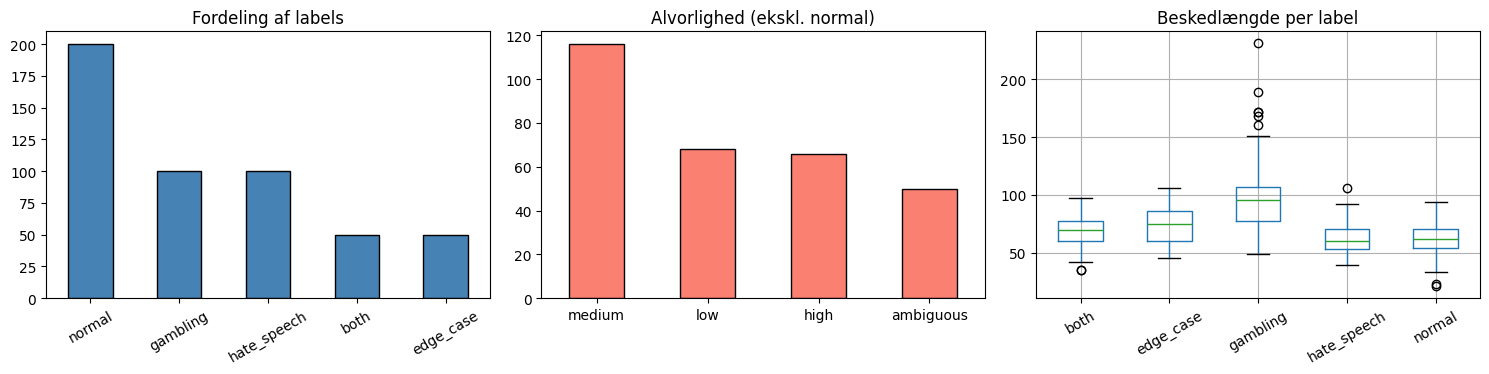

Gemt: dataset_overview.png


In [7]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False

df['msg_length'] = df['content'].str.len()
print("=== Datasæt statistik ===\n")
print(f"Antal beskeder: {len(df)}")
print(f"Antal unikke brugere: {df['user_id'].nunique()}")
print(f"\nGennemsnitlig beskedlængde per label (tegn):")
print(df.groupby('label')['msg_length'].mean().round(1).to_string())
print(f"\nEksempler per kategori:")
for label in df['label'].unique():
    eks = df[df['label'] == label]['content'].iloc[0]
    print(f"\n[{label}]: {eks[:100]}...")


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Labelfordeling
df['label'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Fordeling af labels')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

# 2. Alvorlighed
df[df['severity'] != 'none']['severity'].value_counts().plot(
    kind='bar', ax=axes[1], color='salmon', edgecolor='black'
)
axes[1].set_title('Alvorlighed (ekskl. normal)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

# 3. Beskedlængde per label
df.boxplot(column='msg_length', by='label', ax=axes[2])
axes[2].set_title('Beskedlængde per label')
axes[2].set_xlabel('')
plt.suptitle('')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gemt: dataset_overview.png")

## Fase 3 - AI-klassifikationssystem

Systemet klassificerer beskeder på to dimensioner (grimt sprog og ludomani) 
og udløser handlinger baseret på alvorlighedsniveau. Brugerhistorik indgår 
som kontekst for at fange mønstre over tid frem for kun at vurdere 
den enkelte besked isoleret.

Vi bygger systemet op trinvist:
- Trin 1: Simpelt klassifikationskald
- Trin 2: Parse svar til Python-objekt
- Trin 3: Handlingslogik
- Trin 4: Samlet funktion med brugerhistorik
- Trin 5: Kør på datasættet

### Trin 1 - Simpelt klassifikationskald

In [8]:
# Trin 1: Simpelt klassifikationskald
besked = "tredje gang idag jeg indsætter. ved godt det er for meget"

prompt = f"""Du er et content moderation system for en dansk online casino-platform.

Analysér denne besked og klassificér adfærden:
"{besked}"

Returner KUN dette JSON:
{{
  "hate_speech_severity": "none/low/medium/high",
  "gambling_severity": "none/low/medium/high",
  "reasoning": "kort begrundelse på dansk"
}}"""

response = client.messages.create(
    model="claude-sonnet-4-6",
    max_tokens=300,
    messages=[{"role": "user", "content": prompt}]
)

print(response.content[0].text)

```json
{
  "hate_speech_severity": "none",
  "gambling_severity": "high",
  "reasoning": "Brugeren indsætter penge for tredje gang samme dag og erkender selv, at det er for meget. Dette er et klart tegn på problematisk spilleadfærd og manglende impulskontrol. Selvbevidsthed om overdreven adfærd uden evne til at stoppe er en alvorlig advarselssignal for ludomani, der kræver øjeblikkelig intervention fra platformen."
}
```


### Trin 2 - Parse svar til Python-objekt

In [9]:
# Trin 2: Parse svaret til Python-objekt

raw = response.content[0].text.strip()

# Fjern markdown-fences hvis de er der
if raw.startswith("```"):
    raw = raw.split("\n", 1)[1].rsplit("```", 1)[0].strip()

result = json.loads(raw)

print(f"Grimt sprog: {result['hate_speech_severity']}")
print(f"Ludomani:    {result['gambling_severity']}")
print(f"Begrundelse: {result['reasoning']}")

Grimt sprog: none
Ludomani:    high
Begrundelse: Brugeren indsætter penge for tredje gang samme dag og erkender selv, at det er for meget. Dette er et klart tegn på problematisk spilleadfærd og manglende impulskontrol. Selvbevidsthed om overdreven adfærd uden evne til at stoppe er en alvorlig advarselssignal for ludomani, der kræver øjeblikkelig intervention fra platformen.


### Trin 3 - Handlingslogik

In [10]:
# Trin 3: Handlingslogik baseret på klassifikation

def determine_action(result: dict) -> list[str]:
    hate = result['hate_speech_severity']
    gamble = result['gambling_severity']
    
    actions = []
    
    if hate == 'low':
        actions.append("Send advarsel i chatforum")
    elif hate == 'medium':
        actions.append("Opret sag i backoffice (grimt sprog)")
    elif hate == 'high':
        actions.append("Bloker bruger fra chat")
    
    if gamble == 'low':
        actions.append("Send mail om ansvarligt spil")
    elif gamble == 'medium':
        actions.append("Opret sag i backoffice (ludomani)")
    elif gamble == 'high':
        actions.append("Sæt spilgrænser / selvudelukkelse")
    
    if not actions:
        actions.append("Ingen handling nødvendig")
    
    return actions

actions = determine_action(result)
for action in actions:
    print(action)

Sæt spilgrænser / selvudelukkelse


### Trin 4 - Samlet funktion med brugerhistorik

In [11]:
# Trin 4: Samlet funktion med brugerhistorik

def classify_message(content: str, user_history: list[str]) -> dict:
    
    if user_history:
        history_text = "\n".join([f"- {msg}" for msg in user_history[-5:]])
    else:
        history_text = "Ingen tidligere beskeder"
    
    prompt = f"""Du er et content moderation system for en dansk online casino-platform.

Analysér følgende besked og brugerens seneste historik:

BRUGERENS HISTORIK (seneste beskeder):
{history_text}

NY BESKED:
"{content}"

Returner KUN dette JSON:
{{
  "hate_speech_severity": "none/low/medium/high",
  "gambling_severity": "none/low/medium/high",
  "reasoning": "kort begrundelse på dansk"
}}"""

    response = client.messages.create(
        model="claude-sonnet-4-6",
        max_tokens=300,
        system="Du er et content moderation system. Returner kun valid JSON.",
        messages=[{"role": "user", "content": prompt}]
    )
    
    raw = response.content[0].text.strip()
    if raw.startswith("```"):
        raw = raw.split("\n", 1)[1].rsplit("```", 1)[0].strip()
    
    return json.loads(raw)

# Test med og uden historik
besked = "er lidt frustreret men fortsætter bare"

print("=== UDEN historik ===")
result_uden = classify_message(besked, [])
print(f"Ludomani: {result_uden['gambling_severity']}")
print(f"Begrundelse: {result_uden['reasoning']}\n")

print("=== MED historik ===")
historik = [
    "har tabt 2000 kr idag allerede",
    "okay prøver lige en gang til",
    "tredje gang idag jeg indsætter"
]
result_med = classify_message(besked, historik)
print(f"Ludomani: {result_med['gambling_severity']}")
print(f"Begrundelse: {result_med['reasoning']}")

=== UDEN historik ===
Ludomani: low
Begrundelse: Beskeden udtrykker frustration kombineret med en intention om at fortsætte med at spille. Der er ingen hadefuld tale. Frustrationen over tab kombineret med fortsættelse af spil kan være et svagt tegn på problematisk spilleadfærd, men er isoleret set ikke alarmerende uden yderligere kontekst.

=== MED historik ===
Ludomani: high
Begrundelse: Brugeren har tabt 2000 kr samme dag, foretaget tre indskud og fortsætter nu på trods af frustration. Dette er klassiske tegn på problematisk spilleadfærd: chasing losses, gentagne indskud og emotionel spilsession. Kræver øjeblikkelig intervention.


### Trin 5 - Kør på datasættet

In [12]:
# Trin 5: Kør systemet på et udsnit af datasættet

def process_message(row, df):
    # Hent brugerens historik (tidligere beskeder fra samme bruger)
    history = df[
        (df['user_id'] == row['user_id']) & 
        (df['msg_id'] < row['msg_id'])
    ]['content'].tolist()[-5:]
    
    classification = classify_message(row['content'], history)
    actions = determine_action(classification)
    
    return {
        'msg_id':               row['msg_id'],
        'user_id':              row['user_id'],
        'content':              row['content'],
        'true_label':           row['label'],
        'true_hate_speech':     row['hate_speech'],
        'true_gambling':        row['gambling'],
        'pred_hate_speech':     classification['hate_speech_severity'],
        'pred_gambling':        classification['gambling_severity'],
        'reasoning':            classification['reasoning'],
        'actions':              ', '.join(actions),
    }

# Kør på 100 beskeder: 20 per label
sample = df.groupby('label').apply(
    lambda x: x.sample(20, random_state=42)
).reset_index(drop=True)

print(f"Kører klassifikation på {len(sample)} beskeder...")
results = []

for i, row in sample.iterrows():
    result = process_message(row, df)
    results.append(result)
    if (len(results)) % 10 == 0:
        print(f"  {len(results)}/100 færdig...")

results_df = pd.DataFrame(results)
results_df.to_csv("classification_results.csv", index=False)
print("Færdig! Gemt: classification_results.csv")
print(results_df[['true_label', 'pred_hate_speech', 'pred_gambling', 'actions']].head(10))

Kører klassifikation på 100 beskeder...


/var/folders/yt/3hzr6y7d529d_5n4k1_3xlgr0000gn/T/ipykernel_42955/1689777674.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample = df.groupby('label').apply(


  10/100 færdig...
  20/100 færdig...
  30/100 færdig...
  40/100 færdig...
  50/100 færdig...
  60/100 færdig...
  70/100 færdig...
  80/100 færdig...
  90/100 færdig...
  100/100 færdig...
Færdig! Gemt: classification_results.csv
  true_label pred_hate_speech pred_gambling                            actions
0       both             none          none           Ingen handling nødvendig
1       both             none           low       Send mail om ansvarligt spil
2       both             none        medium  Opret sag i backoffice (ludomani)
3       both             none           low       Send mail om ansvarligt spil
4       both             none           low       Send mail om ansvarligt spil
5       both             none        medium  Opret sag i backoffice (ludomani)
6       both             none          none           Ingen handling nødvendig
7       both             none           low       Send mail om ansvarligt spil
8       both             none           low       Send ma

#### Eksempler på systemets handlinger

In [13]:
print("=== Eksempler på systemets handlinger ===\n")
for action_type in ['Ingen handling', 'Send mail', 'Send advarsel', 'backoffice', 'spilgrænser', 'Bloker']:
    match = results_df[results_df['actions'].str.contains(action_type, case=False, na=False)]
    if len(match) > 0:
        row = match.iloc[0]
        print(f"Handling: {row['actions']}")
        print(f"Besked: {row['content'][:80]}...")
        print(f"Klassifikation: hate={row['pred_hate_speech']}, gambling={row['pred_gambling']}")
        print("-" * 60)

=== Eksempler på systemets handlinger ===

Handling: Ingen handling nødvendig
Besked: Godnat alle, trækker mig med et lille plus, kan man ikke klage over 😄...
Klassifikation: hate=none, gambling=none
------------------------------------------------------------
Handling: Send mail om ansvarligt spil
Besked: Starburst er sgu stadig den bedste slot nogensinde, fight me...
Klassifikation: hate=none, gambling=low
------------------------------------------------------------
Handling: Send advarsel i chatforum, Sæt spilgrænser / selvudelukkelse
Besked: okay jeg er faktisk lidt ligeglad med at jeg tabte, det var en fed runde alligev...
Klassifikation: hate=low, gambling=high
------------------------------------------------------------
Handling: Opret sag i backoffice (ludomani)
Besked: Mega fed session i dag, op med 800 kr så smutter jeg mens jeg er foran hehe...
Klassifikation: hate=none, gambling=medium
------------------------------------------------------------
Handling: Sæt spilgrænser / 

## Fase 3b - Baseline model (TF-IDF + Logistisk Regression)

Vi bygger en simpel baseline som målestok for LLM-systemet. Her defineres
også det testsæt som BEGGE modeller evalueres på i Fase 4, så de kan
sammenlignes direkte. `stratify=df['label']` sikrer at testsættet har samme
klassefordeling som hele datasættet, så accuracy ikke bare belønner den
store normal-klasse.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Ét fælles split — bruges af baseline her og af LLM'en i Fase 4
train_df, test_df = train_test_split(
    df,
    test_size=100,
    random_state=42,
    stratify=df["label"],
)
test_df = test_df.copy()

print(f"Train: {len(train_df)}   Test: {len(test_df)}")
print("\nTestsæt fordeling:")
print(test_df["label"].value_counts().to_string())

# Baseline: TF-IDF + logistisk regression
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(train_df["content"])
X_test_tfidf = vectorizer.transform(test_df["content"])

baseline = LogisticRegression(random_state=42)
baseline.fit(X_train_tfidf, train_df["label"])

test_df["baseline_pred"] = baseline.predict(X_test_tfidf)
print("\nTrain accuracy:", baseline.score(X_train_tfidf, train_df["label"]))
print("Test accuracy: ", baseline.score(X_test_tfidf, test_df["label"]))
# (class_weight="balanced" ville få baseline til at forsøge de små klasser
#  both/edge_case - udeladt her for at holde modellen simpel.)

Train: 400   Test: 100

Testsæt fordeling:
label
normal         40
hate_speech    20
gambling       20
both           10
edge_case      10

Train accuracy: 0.7975
Test accuracy:  0.67


## Fase 4 - Performance evaluering

Vi evaluerer baseline og LLM på det samme testsæt (test_df fra Fase 3b),
så de to modeller kan sammenlignes direkte.

In [15]:
from sklearn.metrics import classification_report, accuracy_score, recall_score
import pandas as pd
import matplotlib.pyplot as plt


# convert_output omsætter LLM'ens to severity-dimensioner til ét label,
# så outputtet kan sammenlignes med datasættets labels.
def convert_output(pred_hate, pred_gambling):
    if pred_hate != "none" and pred_gambling != "none":
        return "both"
    if pred_hate != "none" and pred_gambling == "none":
        return "hate_speech"
    if pred_hate == "none" and pred_gambling != "none":
        return "gambling"
    return "normal"


# LLM evalueres på præcis de samme rækker som baseline (test_df).
# Historik hentes fra hele df: alle tidligere beskeder fra samme bruger.
llm_rows = []
for _, row in test_df.iterrows():
    history = df[
        (df["user_id"] == row["user_id"]) & (df["msg_id"] < row["msg_id"])
    ]["content"].tolist()[-5:]

    try:
        cls = classify_message(row["content"], history)
    except Exception as e:
        print(f"  msg {row['msg_id']}: fejl ({e}) -> none/none")
        cls = {}

    llm_rows.append(
        {
            "msg_id": row["msg_id"],
            "pred_hate_speech": cls.get("hate_speech_severity", "none"),
            "pred_gambling": cls.get("gambling_severity", "none"),
        }
    )
    if len(llm_rows) % 10 == 0:
        print(f"  LLM: {len(llm_rows)}/{len(test_df)}")

llm_df = pd.DataFrame(llm_rows)
llm_df["llm_pred"] = llm_df.apply(
    lambda r: convert_output(r["pred_hate_speech"], r["pred_gambling"]), axis=1
)

eval_df = test_df.merge(llm_df[["msg_id", "llm_pred"]], on="msg_id")
assert len(eval_df) == len(test_df), "Alignment-fejl: rækker matcher ikke"
eval_df.to_csv("eval_shared_testset.csv", index=False)
print(f"\nBegge modeller scoret på samme {len(eval_df)} rækker.")

  LLM: 10/100
  LLM: 20/100
  LLM: 30/100
  LLM: 40/100
  LLM: 50/100
  LLM: 60/100
  LLM: 70/100
  LLM: 80/100
  LLM: 90/100
  LLM: 100/100

Begge modeller scoret på samme 100 rækker.


### 5-klasse rapport (begge på samme testsæt)
Bemærk: 5-klasse er strukturelt unfair mod LLM'en — den kan aldrig
returnere "edge_case" (convert_output har ingen sti dertil). Den binære
evaluering nedenfor er derfor den retfærdige sammenligning.

In [16]:
print("=== BASELINE (5-klasse) ===")
print(classification_report(eval_df["label"], eval_df["baseline_pred"], zero_division=0))

print("=== LLM (5-klasse) ===")
print(classification_report(eval_df["label"], eval_df["llm_pred"], zero_division=0))

=== BASELINE (5-klasse) ===
              precision    recall  f1-score   support

        both       0.00      0.00      0.00        10
   edge_case       1.00      0.10      0.18        10
    gambling       0.79      0.75      0.77        20
 hate_speech       1.00      0.65      0.79        20
      normal       0.57      0.95      0.71        40

    accuracy                           0.67       100
   macro avg       0.67      0.49      0.49       100
weighted avg       0.68      0.67      0.61       100

=== LLM (5-klasse) ===
              precision    recall  f1-score   support

        both       0.00      0.00      0.00        10
   edge_case       0.00      0.00      0.00        10
    gambling       0.24      0.90      0.38        20
 hate_speech       0.78      0.35      0.48        20
      normal       0.71      0.12      0.21        40

    accuracy                           0.30       100
   macro avg       0.35      0.28      0.22       100
weighted avg       0.49   

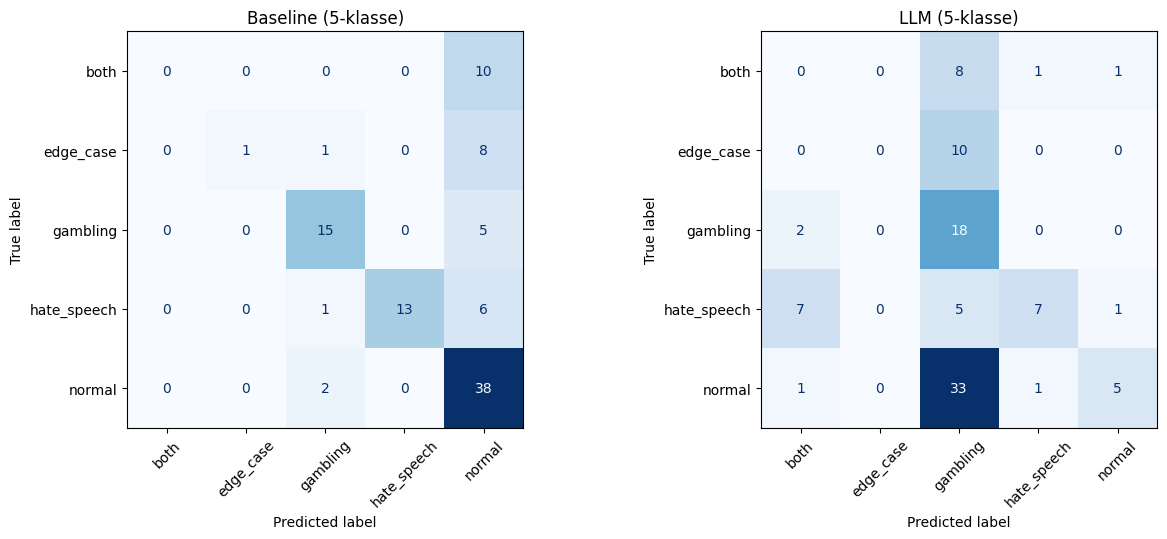

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

labels5 = ["both", "edge_case", "gambling", "hate_speech", "normal"]
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, (name, col) in zip(axes, [("Baseline", "baseline_pred"), ("LLM", "llm_pred")]):
    cm = confusion_matrix(eval_df["label"], eval_df[col], labels=labels5)
    ConfusionMatrixDisplay(cm, display_labels=labels5).plot(
        ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45
    )
    ax.set_title(f"{name} (5-klasse)")
plt.tight_layout()
plt.savefig("confusion_5klasse_shared.png", dpi=150, bbox_inches="tight")
plt.show()

### Binær evaluering (problematisk vs. normal) — den fair sammenligning

In [18]:
for col in ["baseline_pred", "llm_pred"]:
    eval_df[col + "_bin"] = eval_df[col].apply(
        lambda x: "normal" if x == "normal" else "problematisk"
    )
eval_df["true_bin"] = eval_df["label"].apply(
    lambda x: "normal" if x == "normal" else "problematisk"
)

print("=== BASELINE (binær) ===")
print(classification_report(eval_df["true_bin"], eval_df["baseline_pred_bin"], zero_division=0))
print("=== LLM (binær) ===")
print(classification_report(eval_df["true_bin"], eval_df["llm_pred_bin"], zero_division=0))

=== BASELINE (binær) ===
              precision    recall  f1-score   support

      normal       0.57      0.95      0.71        40
problematisk       0.94      0.52      0.67        60

    accuracy                           0.69       100
   macro avg       0.75      0.73      0.69       100
weighted avg       0.79      0.69      0.68       100

=== LLM (binær) ===
              precision    recall  f1-score   support

      normal       0.71      0.12      0.21        40
problematisk       0.62      0.97      0.76        60

    accuracy                           0.63       100
   macro avg       0.67      0.55      0.49       100
weighted avg       0.66      0.63      0.54       100



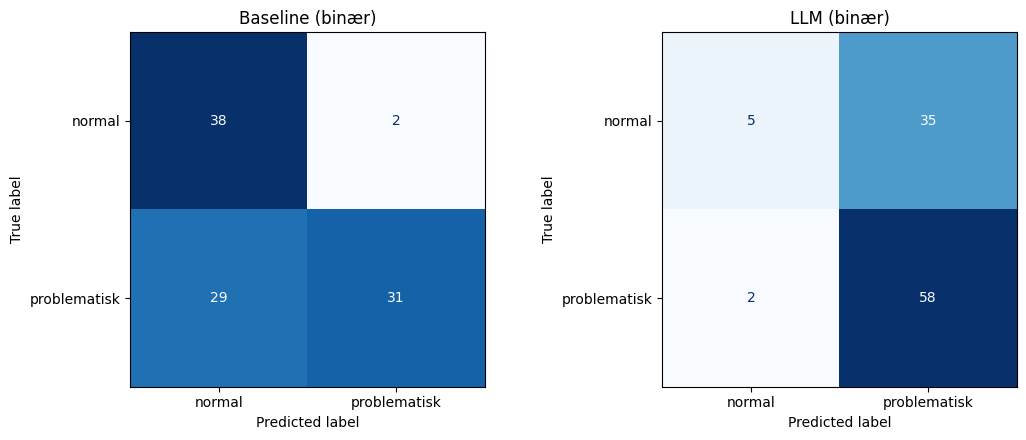

In [19]:
labels_bin = ["normal", "problematisk"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, col) in zip(axes, [("Baseline", "baseline_pred_bin"), ("LLM", "llm_pred_bin")]):
    cm = confusion_matrix(eval_df["true_bin"], eval_df[col], labels=labels_bin)
    ConfusionMatrixDisplay(cm, display_labels=labels_bin).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{name} (binær)")
plt.tight_layout()
plt.savefig("confusion_binar_shared.png", dpi=150, bbox_inches="tight")
plt.show()

                     Baseline   LLM
Accuracy                 0.69  0.63
Recall problematisk      0.52  0.97
Recall normal            0.95  0.12


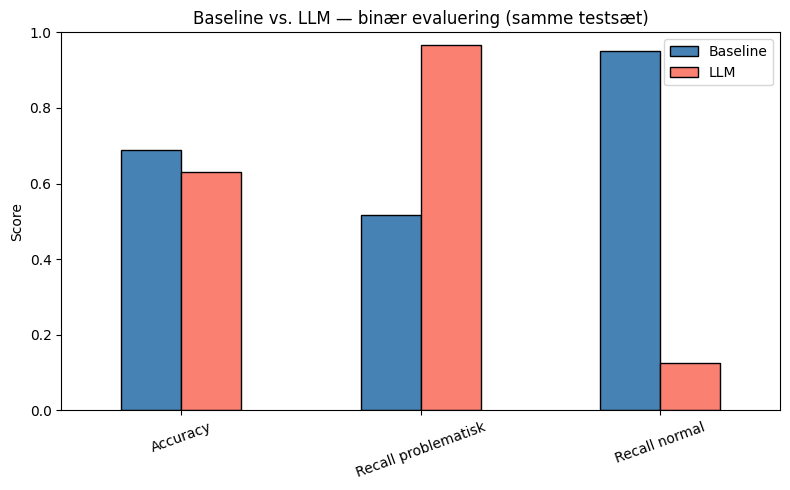

In [20]:
# Sammenligningstabel - beregnet fra det fælles testsæt
def binary_scores(true_bin, pred_bin):
    return {
        "Accuracy": accuracy_score(true_bin, pred_bin),
        "Recall problematisk": recall_score(
            true_bin, pred_bin, pos_label="problematisk", zero_division=0
        ),
        "Recall normal": recall_score(
            true_bin, pred_bin, pos_label="normal", zero_division=0
        ),
    }

comparison = pd.DataFrame(
    {
        "Baseline": binary_scores(eval_df["true_bin"], eval_df["baseline_pred_bin"]),
        "LLM": binary_scores(eval_df["true_bin"], eval_df["llm_pred_bin"]),
    }
)
print(comparison.round(2))

comparison.plot(kind="bar", figsize=(8, 5), color=["steelblue", "salmon"], edgecolor="black")
plt.title("Baseline vs. LLM — binær evaluering (samme testsæt)")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("comparison_shared_testset.png", dpi=150, bbox_inches="tight")
plt.show()

## Fase 5 - Refleksion
### Kontekstvinduets betydning
Brugerhistorik er afgørende for at fange mønstre over tid. En enkelt besked 
som "er lidt frustreret men fortsætter bare" klassificeres som lav risiko uden 
kontekst, men som høj risiko (chasing losses) når historikken viser gentagne 
indskud og store tab samme dag. Kontekstvinduet er sat til de 5 seneste beskeder 
— et større vindue ville fange længerevarende mønstre, men øge latency og pris.

### Håndtering af edge cases
Sarkasme, ironi og slang er systemets svageste punkt. En besked som "fedt, endnu 
et tab" kan være ironisk frustration eller ægte bekymrende adfærd. Confusion matrix 
viser at edge cases er svære: alle 10 edge case-beskeder i testsættet klassificeres 
som gambling, fordi de typisk nævner spil-relateret indhold uden klar problematisk 
adfærd. Det afspejler en strukturel begrænsning - convert_output kan ikke producere 
labelet "edge_case", så de kan aldrig rammes korrekt i 5-klasse-formatet.

### False positives vs. false negatives
De to kategorier har asymmetriske konsekvenser:

**Grimt sprog:** En false positive (uskyldig bruger advares) koster kundeoplevelse 
og tillid. En false negative (grov chikane misses) skader andre brugere. 
Her er præcision vigtig — baseline foretrækkes.

**Ludomani:** En false positive (bruger får mail om ansvarligt spil) er harmløs. 
En false negative (bruger med spilleproblemer misses) kan have alvorlige konsekvenser 
for brugerens velfærd og CEGOs ansvar over for ansvarligt spil-regulering. 
Her er recall vigtig - LLM foretrækkes.

### Baseline vs. LLM - fundamental forskel:
Baseline klassificerer i faste kategorier uden alvorlighedsvurdering og uden 
brugerhistorik. En direkte sammenligning på 5-klasse accuracy er derfor misvisende. 
Den binære evaluering (problematisk vs. normal) er en mere fair sammenligning 
da den måler det der faktisk betyder noget i produktion: fanger systemet 
problematisk adfærd overhovedet?


### Forbedringer med mere tid
- Rigtige chatdata frem for syntetisk genereret data
- Finjustering af prompt baseret på fejlkategorier fra confusion matrix
- Ensemble-tilgang: baseline til grove kategorier, LLM til edge cases
- Aktiv læring: menneskelig review af usikre klassifikationer

## Konklusion

LLM'en er markant bedre til at fange problematisk adfærd (recall 0.97 vs. 0.52), 
men på bekostning af mange false positives på normale beskeder (recall normal 0.12 vs. 0.95).

Baseline er mere præcis og konservativ, men misser næsten halvdelen af problematiske beskeder.

De absolutte LLM-tal afspejler desuden en reel domæneudfordring: på en casinoside 
handler selv normale beskeder naturligt om spil (gevinster, tips, indskud). Den svære 
opgave er derfor ikke at opdage gambling-emnet, men at skelne mellem at *tale om* spil 
(normalt) og at *udvise tegn på* problematisk spil (ludomani). En del af LLM'ens 
"false positives" rammer netop denne grænse - de er diskutable tilfælde snarere end 
rene fejl.

**Anbefaling til produktion:**
- Ludomani: LLM foretrækkes - en missed detection er potentielt meget skadelig
- Grimt sprog: Baseline eller kombination - false positives koster kundeoplevelse
- Hastighed: Baseline er markant hurtigere og billigere at skalere

**Næste skridt:**
- Evaluér LLM'en per alvorlighedsakse (hate / gambling hver for sig) i stedet for 
  ét samlet label - det måler systemet på dets egne præmisser
- Indfør eskalation over tid: lad handlinger udløses af mønstre på tværs af en brugers 
  beskeder frem for én enkelt besked
- Skærp definitionen af grænsen mellem normal spilomtale og problematisk adfærd - 
  evt. med flere bevidst tvetydige eksempler i træningsdata, så modellen lærer 
  netop den skelnen